# MNIST Digit Classification with Neural Networks (Classroom Edition)
## Math 280: Mathematical and Statistical Foundations of Data Science
### Spring 2026 — Based on ISLR Section 10.9.2

---

This notebook is a **lightweight version** of the full ISLR Section 10.9.2 example, designed to run in a 50-minute class session.

**What we change from the full ISLR version (and why):**
| | Full ISLR | This notebook |
|---|---|---|
| Training images | 60,000 | 10,000 (subsampled) |
| Test images | 10,000 | 2,000 (subsampled) |
| Image size | 28×28 = 784 pixels | 14×14 = 196 pixels |
| Hidden layer 1 | 256 units | 64 units |
| Hidden layer 2 | 128 units | 32 units |
| Total parameters | 235,146 | ~15,000 |
| Training time | ~2–3 min | ~15–20 sec |

All the key ideas carry over exactly — we're just turning down the resolution and scale.

---
## 0. Setup and Imports

## A note on TensorFlow/Keras

In Python, neural networks are typically built using **TensorFlow** and its high-level API **Keras** — these are the Python equivalents of the `keras` package used in the R code in ISLR Section 10.9.2.

TensorFlow is not pre-installed on our JupyterHub, so before running this notebook you'll need to install it. Open a terminal or run the following in a notebook cell:
```bash
pip install tensorflow
```

Once installed, you should not need to reinstall it in future sessions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print("TensorFlow version:", tf.__version__)
tf.random.set_seed(280)
np.random.seed(280)

/Users/suzanne/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.20.0


---
## 1. Load MNIST and Subsample

MNIST has 60,000 training and 10,000 test images. We take a **stratified subsample** — equal numbers of each digit class — so the class balance is preserved.

We use **10,000 training** and **2,000 test** images (1,000 and 200 per class, respectively).

In [2]:
# Load the full MNIST dataset
(x_train_full, g_train_full), (x_test_full, g_test_full) = keras.datasets.mnist.load_data()

print("Full dataset sizes:")
print(f"  Training: {x_train_full.shape}")
print(f"  Test:     {x_test_full.shape}")

# --- Stratified subsample: n_per_class images per digit ---
def stratified_subsample(X, g, n_per_class, rng_seed=280):
    """Return n_per_class examples of each digit 0-9, sampled without replacement."""
    rng = np.random.default_rng(rng_seed)
    idx = np.concatenate([
        rng.choice(np.where(g == k)[0], size=n_per_class, replace=False)
        for k in range(10)
    ])
    rng.shuffle(idx)   # shuffle so classes aren't in blocks
    return X[idx], g[idx]

# 1,000 examples per class -> 10,000 training images
x_train_sub, g_train_sub = stratified_subsample(x_train_full, g_train_full, n_per_class=1000)
# 200 examples per class  ->  2,000 test images
x_test_sub,  g_test_sub  = stratified_subsample(x_test_full,  g_test_full,  n_per_class=200)

print(f"\nSubsampled dataset sizes:")
print(f"  Training: {x_train_sub.shape}")
print(f"  Test:     {x_test_sub.shape}")
print(f"  Class counts in training: { {k: np.sum(g_train_sub==k) for k in range(10)} }")

Full dataset sizes:
  Training: (60000, 28, 28)
  Test:     (10000, 28, 28)

Subsampled dataset sizes:
  Training: (10000, 28, 28)
  Test:     (2000, 28, 28)
  Class counts in training: {0: np.int64(1000), 1: np.int64(1000), 2: np.int64(1000), 3: np.int64(1000), 4: np.int64(1000), 5: np.int64(1000), 6: np.int64(1000), 7: np.int64(1000), 8: np.int64(1000), 9: np.int64(1000)}


---
## 2. Downsample Images: 28×28 → 14×14

Each image is 28×28 pixels. We reduce to **14×14** by taking every other pixel in each direction (2× subsampling). This:
- Reduces the input dimension from 784 → **196** (4× fewer inputs)
- Makes the first layer ~4× smaller
- Loses some fine detail, but digit structure is well-preserved

We use TensorFlow's `tf.image.resize` for clean bilinear downsampling.

Image size after downsampling: (14, 14)


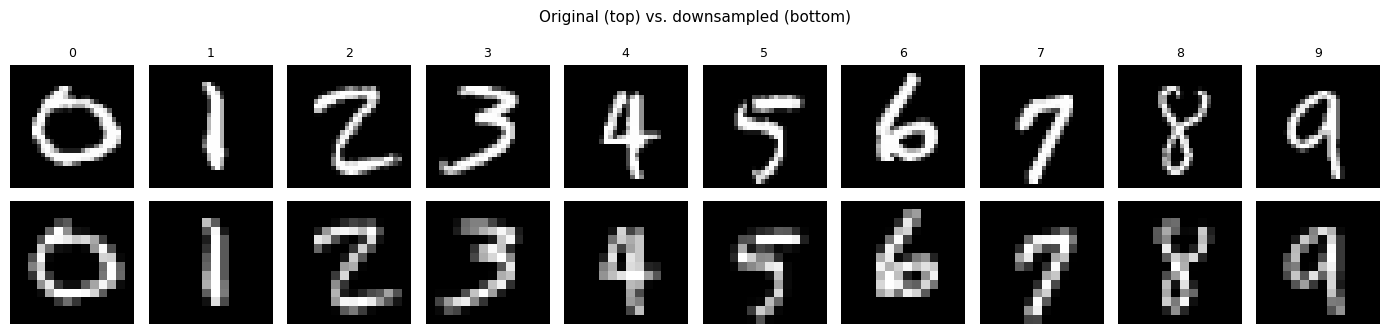

In [3]:
def downsample_images(X, new_size=(14, 14)):
    """Resize a batch of grayscale images from 28x28 to new_size using bilinear interpolation."""
    # tf.image.resize expects shape (batch, H, W, channels)
    X_4d = X[..., np.newaxis].astype('float32')   # add channel dim
    X_resized = tf.image.resize(X_4d, new_size, method='bilinear').numpy()
    return X_resized[..., 0]   # remove channel dim -> (batch, 14, 14)

x_train_small = downsample_images(x_train_sub)
x_test_small  = downsample_images(x_test_sub)

print(f"Image size after downsampling: {x_train_small.shape[1:]}")

# Show a side-by-side comparison: original 28x28 vs downsampled 14x14
fig, axes = plt.subplots(2, 10, figsize=(14, 3.5))
for i in range(10):
    idx = np.where(g_train_sub == i)[0][0]
    axes[0, i].imshow(x_train_sub[idx], cmap='gray', interpolation='nearest')
    axes[0, i].set_title(f"{i}", fontsize=9)
    axes[0, i].axis('off')
    axes[1, i].imshow(x_train_small[idx], cmap='gray', interpolation='nearest')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('28×28', fontsize=8)
axes[1, 0].set_ylabel('14×14', fontsize=8)
plt.suptitle('Original (top) vs. downsampled (bottom)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. Preprocess: Flatten, Rescale, One-Hot Encode

Same three steps as the full ISLR example — just applied to our smaller images.

- **Flatten**: 14×14 → vector of length 196
- **Rescale**: pixel values [0, 255] → [0, 1]
- **One-hot encode** the integer labels 0–9

In [ ]:
# Flatten: (N, 14, 14) -> (N, 196)
x_train = x_train_small.reshape(-1, 196).astype('float32') / 255.0
x_test  = x_test_small.reshape(-1,  196).astype('float32') / 255.0

# One-hot encode labels
y_train = to_categorical(g_train_sub, num_classes=10)
y_test  = to_categorical(g_test_sub,  num_classes=10)

print(f"x_train shape: {x_train.shape}  (input dimension = 196)")
print(f"y_train shape: {y_train.shape}")
print(f"\nExample: digit {g_train_sub[0]}  ->  {y_train[0]}")

---
## 4. Build the Neural Network

We scale the ISLR architecture down to match our smaller input and dataset size.

| | ISLR (full) | This notebook |
|---|---|---|
| Input units | 784 | **196** |
| Hidden layer 1 | 256 units | **64 units** |
| Hidden layer 2 | 128 units | **32 units** |
| Output | 10 (softmax) | 10 (softmax) |
| Dropout rates | 0.4, 0.3 | 0.3, 0.2 |

The structure and all the ideas are identical — ReLU activations, dropout, softmax output.

In [ ]:
modelnn = keras.Sequential([

    # Explicit Input layer — the modern Keras way to specify input shape
    # (avoids deprecation warning from passing input_shape= to Dense directly)
    keras.Input(shape=(196,)),

    # Hidden layer 1: 196 inputs -> 64 units, ReLU
    # Parameters: (196 + 1) × 64 = 12,608
    layers.Dense(64, activation='relu', name='hidden_1'),

    # Dropout: zero out 30% of activations randomly during training
    layers.Dropout(0.3, name='dropout_1'),

    # Hidden layer 2: 64 inputs -> 32 units, ReLU
    # Parameters: (64 + 1) × 32 = 2,080
    layers.Dense(32, activation='relu', name='hidden_2'),

    # Dropout: zero out 20% of activations randomly during training
    layers.Dropout(0.2, name='dropout_2'),

    # Output layer: 32 inputs -> 10 class probabilities via softmax
    # Parameters: (32 + 1) × 10 = 330
    layers.Dense(10, activation='softmax', name='output')
])

modelnn.summary()
print("\n(ISLR full model had 235,146 parameters — we have ~15x fewer)")

---
## 5. Compile and Train

Same loss, same optimizer as ISLR. We use 20 epochs (vs. 30) since the smaller dataset converges faster.

**Gradient steps per epoch check:**  
Training set after 80/20 validation split: $10000 \times 0.8 = 8000$ observations.  
With batch size 128: $\lceil 8000/128 \rceil = 63$ gradient steps per epoch.

In [ ]:
modelnn.compile(
    loss='categorical_crossentropy',
    optimizer='rmsprop',
    metrics=['accuracy']
)

history = modelnn.fit(
    x_train, y_train,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

---
## 6. Plot Training History

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'],     label='Train',      color='steelblue')
ax1.plot(history.history['val_accuracy'], label='Validation', color='tomato', linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy'); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train',      color='steelblue')
ax2.plot(history.history['val_loss'], label='Validation', color='tomato', linestyle='--')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Cross-entropy loss')
ax2.set_title('Loss'); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Training history (analog of ISLR Figure 10.18)', fontsize=12)
plt.tight_layout()
plt.show()

---
## 7. Evaluate on the Test Set

In [ ]:
pred_probs   = modelnn.predict(x_test)
pred_classes = np.argmax(pred_probs, axis=1)
test_acc = np.mean(pred_classes == g_test_sub)

print(f"Test accuracy (neural network, lite): {test_acc:.4f}")
print(f"  (Full ISLR model achieves ~0.981 on full test set)")
print(f"  Some accuracy loss is expected: fewer training examples, lower-res images, smaller network.")

# Confusion matrix
cm = confusion_matrix(g_test_sub, pred_classes)
fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion matrix — neural network (lite)')
plt.tight_layout()
plt.show()

---
## 8. Baseline: Multinomial Logistic Regression

A neural network with **no hidden layers** is exactly multinomial logistic regression.  
This is a useful baseline — and it's fast to fit.

In [ ]:
modellr = keras.Sequential([
    keras.Input(shape=(196,)),
    layers.Dense(10, activation='softmax', name='output')
])
modellr.summary()

modellr.compile(loss='categorical_crossentropy', optimizer='rmsprop', metrics=['accuracy'])

modellr.fit(
    x_train, y_train,
    epochs=20, batch_size=128, validation_split=0.2, verbose=1
)

pred_lr = np.argmax(modellr.predict(x_test), axis=1)
lr_acc  = np.mean(pred_lr == g_test_sub)
print(f"\nTest accuracy (logistic regression, lite): {lr_acc:.4f}")
print(f"Test accuracy (neural network, lite):      {test_acc:.4f}")

---
## 9. Look at Misclassified Digits

In [ ]:
wrong = np.where(pred_classes != g_test_sub)[0]
print(f"Misclassified: {len(wrong)} out of {len(g_test_sub)}")

n_show = min(20, len(wrong))
fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i, idx in enumerate(wrong[:n_show]):
    ax = axes[i // 10, i % 10]
    ax.imshow(x_test_small[idx], cmap='gray', interpolation='nearest')
    ax.set_title(f"T:{g_test_sub[idx]} P:{pred_classes[idx]}", fontsize=7, color='red')
    ax.axis('off')
plt.suptitle('Misclassified examples (T=true label, P=predicted)', fontsize=11)
plt.tight_layout()
plt.show()

---
## 10. Comparison Summary

Run this cell to print a clean summary table.

In [ ]:
print("=" * 55)
print(f"{'Model':<30} {'Params':>8} {'Test Acc':>10}")
print("-" * 55)
print(f"{'Logistic regression (lite)':<30} {'1,970':>8} {lr_acc:>10.4f}")
print(f"{'Neural network (lite)':<30} {'~15k':>8} {test_acc:>10.4f}")
print("-" * 55)
print(f"{'Neural network (ISLR full)':<30} {'235k':>8} {'~0.981':>10}")
print("=" * 55)
print("\nNote: accuracy gap vs full ISLR is expected due to:")
print("  - 6x fewer training images")
print("  - 4x lower image resolution (14x14 vs 28x28)")
print("  - ~15x fewer network parameters")

---
## Discussion Questions

1. **Resolution trade-off**: We dropped from 784 to 196 pixels. For which digits do you expect the most accuracy loss, and why?

2. **Sample size**: What happens to train vs. validation accuracy as you increase `n_per_class` from 200 → 500 → 1000? What does this tell you about the bias-variance trade-off?

3. **Dropout**: Try setting all dropout rates to 0. How does the training vs. validation accuracy gap change?

4. **Architecture**: The full ISLR network has ~15x more parameters but only ~5 percentage points more accuracy. What does this suggest about diminishing returns in neural network scaling?

5. **Logistic regression vs. neural network**: The gap here is smaller than in ISLR's full example. Why might the relative advantage of hidden layers shrink with lower-resolution inputs?

---
*Math 280, Spring 2026. Classroom edition of ISLR Section 10.9.2.*  
*Python/TensorFlow translation of the original R/Keras code from James, Witten, Hastie, and Tibshirani.*  
*This notebook was developed with AI assistance.*